In [1721]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("bengaluru_house_prices.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [1610]:
df.shape

(13320, 9)

In [1611]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [1612]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [1613]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2117,), dtype=object)

In [1614]:
def sqft_conversion(record):
    try:
        if '-' in record:
            values= record.split('-')
            avg= (float(values[0].strip()) + float(values[1].strip())) / 2
            return avg
        else:
            return float(record)
    except:
        return None
        
df['total_sqft']= df['total_sqft'].apply(sqft_conversion)

In [1615]:
df.shape

(13320, 9)

In [1616]:
df.dropna(subset= ['total_sqft'], inplace= True)

In [1617]:
df.shape

(13274, 9)

In [1618]:
df.duplicated().sum()

np.int64(529)

In [1619]:
df.drop_duplicates(inplace= True)

In [1620]:
df.shape

(12745, 9)

In [1621]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [1622]:
df['size']= df['size'].str.split(' ').str[0]

In [1623]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00


In [1624]:
df['size'].isnull().sum()

np.int64(16)

In [1625]:
df.dropna(subset= ['size'], inplace= True)

In [1626]:
df['size']= df['size'].astype(int)

In [1627]:
df.isnull().sum()

area_type          0
availability       0
location           1
size               0
society         5295
total_sqft         0
bath              57
balcony          585
price              0
dtype: int64

In [1628]:
df.dropna(subset= ['location'], inplace= True)

In [1629]:
df['bath'].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [1630]:
df.describe()

,size,total_sqft,bath,balcony,price
count,12728.000000,12728.000000,12671.000000,12143.000000,12728.000000
mean,2.816782,1568.765510,2.707127,1.583628,114.228781
std,1.308978,1259.945431,1.355225,0.822034,151.617682
min,1.000000,1.000000,1.000000,0.000000,8.000000
25%,2.000000,1100.000000,2.000000,1.000000,50.000000
50%,3.000000,1280.000000,2.000000,2.000000,73.000000
75%,3.000000,1690.000000,3.000000,2.000000,120.000000
max,43.000000,52272.000000,40.000000,3.000000,3600.000000


In [1631]:
df['balcony'].unique()

array([ 1.,  3., nan,  2.,  0.])

In [1632]:
df['balcony'].isnull().sum()

np.int64(585)

In [1633]:
df['bath'].fillna(value= df['bath'].median(), inplace= True)

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\3369600543.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(value= df['bath'].median(), inplace= True)


In [1634]:
df['bath'].isnull().sum()

np.int64(0)

In [1635]:
df['balcony'].fillna(value= df['balcony'].mean(), inplace= True)

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\1805784122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(value= df['balcony'].mean(), inplace= True)


In [1636]:
df['balcony'].isnull().sum()

np.int64(0)

In [1637]:
df.isnull().sum()

area_type          0
availability       0
location           0
size               0
society         5295
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64

In [1638]:
df.drop(columns= ['society'], inplace= True)

In [1639]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [1640]:
df.duplicated().sum()

np.int64(39)

In [1641]:
df.drop_duplicates(inplace= True)

In [1642]:
df.shape

(12689, 8)

In [1643]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  object 
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 892.2+ KB


In [1644]:
df.head(10)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1056.0,2.0,1.000000,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5.0,3.000000,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2.0,3.000000,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3.0,1.000000,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2.0,1.000000,51.00
5,Super built-up Area,Ready To Move,Whitefield,2,1170.0,2.0,1.000000,38.00
6,Super built-up Area,18-May,Old Airport Road,4,2732.0,4.0,1.583628,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,3300.0,4.0,1.583628,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3,1310.0,3.0,1.000000,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6,1020.0,6.0,1.583628,370.00


In [1645]:
df['size'].dtype

dtype('int64')

In [1646]:
df['size'].head()

0    2
1    4
2    3
3    3
4    2
Name: size, dtype: int64

In [1647]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  object 
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 892.2+ KB


In [1648]:
df.head(10)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1056.0,2.0,1.000000,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5.0,3.000000,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2.0,3.000000,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3.0,1.000000,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2.0,1.000000,51.00
5,Super built-up Area,Ready To Move,Whitefield,2,1170.0,2.0,1.000000,38.00
6,Super built-up Area,18-May,Old Airport Road,4,2732.0,4.0,1.583628,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,3300.0,4.0,1.583628,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3,1310.0,3.0,1.000000,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6,1020.0,6.0,1.583628,370.00


In [1649]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8267
Built-up  Area          2381
Plot  Area              1955
Carpet  Area              86
Name: count, dtype: int64

In [1650]:
df['availability'].value_counts()

availability
Ready To Move    10100
18-May             289
18-Dec             282
18-Apr             269
18-Aug             186
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 80, dtype: int64

In [1651]:
df['availability']= np.where(df['availability'] == 'Ready To Move', 1, 0)

In [1652]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 892.2+ KB


In [1653]:
df['location'].value_counts()

location
Whitefield           520
Sarjapur  Road       377
Electronic City      286
Kanakpura Road       240
Thanisandra          228
                    ... 
Vidyapeeta             1
Maruthi Extension      1
Okalipura              1
Old Town               1
Abshot Layout          1
Name: count, Length: 1298, dtype: int64

In [1654]:
rare_locations = df['location'].value_counts()[df['location'].value_counts() < 50].index

df['location']= np.where(df['location'].isin(rare_locations), 'other', df['location'])

In [1655]:
df['location'].value_counts()

location
other                       7436
Whitefield                   520
Sarjapur  Road               377
Electronic City              286
Kanakpura Road               240
Thanisandra                  228
Yelahanka                    209
Marathahalli                 169
Hebbal                       161
Raja Rajeshwari Nagar        159
Uttarahalli                  154
Bannerghatta Road            148
Hennur Road                  146
7th Phase JP Nagar           132
Electronic City Phase II     127
Rajaji Nagar                 107
Haralur Road                  99
Bellandur                     93
KR Puram                      91
Electronics City Phase 1      88
Hoodi                         88
Yeshwanthpur                  83
Chandapura                    82
Sarjapur                      81
Kasavanhalli                  78
Harlur                        76
Hormavu                       73
Begur Road                    72
Kengeri                       72
Banashankari                  71
R

In [1656]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 892.2+ KB


In [1657]:
df['bath']= df['bath'].astype('int')
df['balcony']= df['balcony'].astype('int')

In [1658]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  int64  
 6   balcony       12689 non-null  int64  
 7   price         12689 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 892.2+ KB


In [1659]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,39.07
1,Plot Area,1,other,4,2600.0,5,3,120.00
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,62.00
3,Super built-up Area,1,other,3,1521.0,3,1,95.00
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,51.00


In [1660]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [1661]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,1,other,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,1,other,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,51.00,4250.000000


In [1662]:
df['price'] = (df['price'] * 100000)

In [1663]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606
1,Plot Area,1,other,4,2600.0,5,3,12000000.0,4615.384615
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,6200000.0,4305.555556
3,Super built-up Area,1,other,3,1521.0,3,1,9500000.0,6245.890861
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,5100000.0,4250.000000


In [1664]:
df['price_per_sqft'].describe()

count    1.268900e+04
mean     8.039058e+03
std      1.088525e+05
min      2.678298e+02
25%      4.300000e+03
50%      5.490196e+03
75%      7.407407e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [1665]:
df.describe()

,availability,size,total_sqft,bath,balcony,price,price_per_sqft
count,12689.000000,12689.000000,12689.000000,12689.000000,12689.000000,1.268900e+04,1.268900e+04
mean,0.795965,2.818347,1569.800016,2.705729,1.556939,1.143993e+07,8.039058e+03
std,0.403011,1.310433,1261.652791,1.354584,0.812939,1.518104e+07,1.088525e+05
min,0.000000,1.000000,1.000000,1.000000,0.000000,8.000000e+05,2.678298e+02
25%,1.000000,2.000000,1100.000000,2.000000,1.000000,5.000000e+06,4.300000e+03
50%,1.000000,3.000000,1280.000000,2.000000,2.000000,7.300000e+06,5.490196e+03
75%,1.000000,3.000000,1691.000000,3.000000,2.000000,1.210000e+07,7.407407e+03
max,1.000000,43.000000,52272.000000,40.000000,3.000000,3.600000e+08,1.200000e+07


In [1666]:
result= []

for i in df['location'].unique():
    location_categories= df[df['location'] == i]
    lower= (location_categories['price_per_sqft'].mean()) - (location_categories['price_per_sqft'].std())
    upper= (location_categories['price_per_sqft'].mean()) + (location_categories['price_per_sqft'].std())
    result.append(location_categories[(location_categories['price_per_sqft'] >= lower) & (location_categories['price_per_sqft'] <= upper)])
    
df= pd.concat(result)

In [1667]:
df.shape

(11967, 9)

In [1668]:
df= df[df['price'] <= 50000000]

df.shape

(11768, 9)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

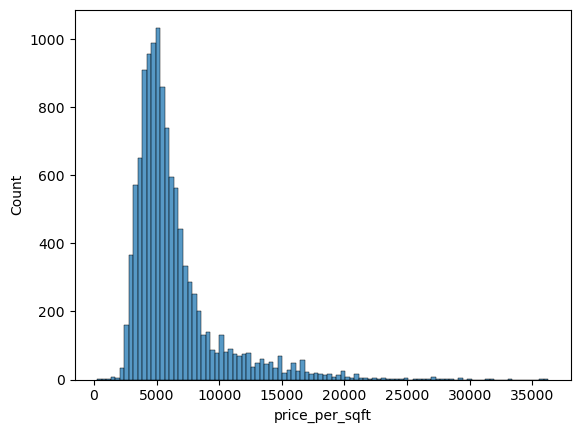

In [1669]:
sns.histplot(df['price_per_sqft'], bins= 100)

In [1670]:
df['price_per_sqft'].describe()

count    11768.000000
mean      6382.372148
std       3474.341555
min        267.829813
25%       4306.742750
50%       5405.405405
75%       7048.214286
max      36274.509804
Name: price_per_sqft, dtype: float64

In [1671]:
top_loc= df.groupby('location')['price_per_sqft'].mean().sort_values(ascending= False).head(10)

In [1672]:
top_loc

location
Rajaji Nagar          13896.399539
Malleshwaram          11824.221331
Koramangala            9688.631442
Nagarbhavi             8169.260420
Hebbal                 7282.042555
other                  6867.144814
Harlur                 6517.938769
7th Phase JP Nagar     6472.926702
Jakkur                 6279.041405
Yeshwanthpur           6277.680125
Name: price_per_sqft, dtype: float64

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\3100035216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_loc.index, x=top_loc.values, palette='Blues_r')


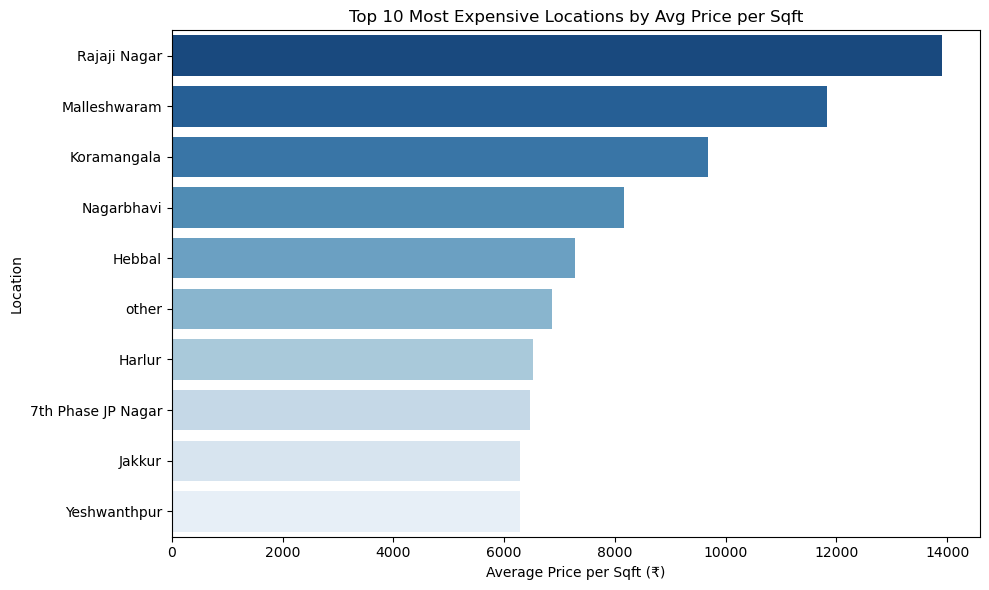

In [1673]:
plt.figure(figsize=(10, 6)) # Set size of fig, default size is smaller
sns.barplot(y=top_loc.index, x=top_loc.values, palette='Blues_r')
plt.title('Top 10 Most Expensive Locations by Avg Price per Sqft')
plt.xlabel('Average Price per Sqft (₹)')
plt.ylabel('Location')
plt.tight_layout() # Prevent overlapping
plt.show()

# Always use bar graphs for categorical data & histogram for numerical data.
# Learned about groupby function, it group unique rows and we can perform operations on the group. Its returns a series where index are the groups and values are the output of operations we performed.

<Axes: xlabel='size', ylabel='price'>

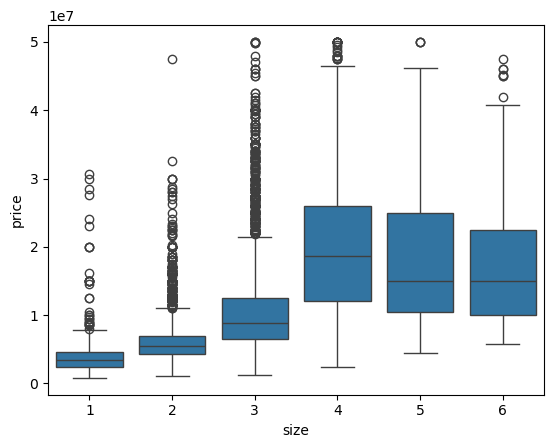

In [1674]:
temp= df[df['size'] <= 6]
sns.boxplot(x= temp["size"], y= temp["price"])

<Axes: xlabel='bath', ylabel='price'>

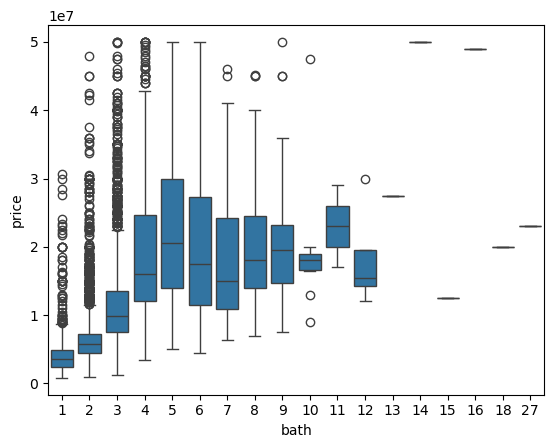

In [1675]:
sns.boxplot(x= df["bath"], y= df["price"])

In [1676]:
df= df[(df['bath'] <= df['size']+2)]

In [1677]:
df.shape

(11760, 9)

<Axes: xlabel='size', ylabel='count'>

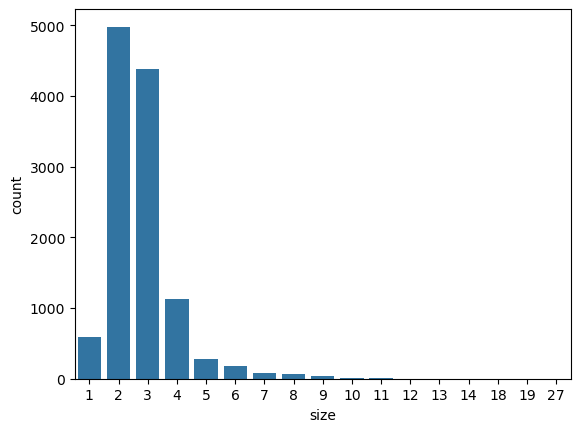

In [1678]:
sns.countplot(x=df['size'])

In [1679]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11760 entries, 0 to 12810
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       11760 non-null  object 
 1   availability    11760 non-null  int64  
 2   location        11760 non-null  object 
 3   size            11760 non-null  int64  
 4   total_sqft      11760 non-null  float64
 5   bath            11760 non-null  int64  
 6   balcony         11760 non-null  int64  
 7   price           11760 non-null  float64
 8   price_per_sqft  11760 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 918.8+ KB


<Axes: xlabel='area_type', ylabel='price_per_sqft'>

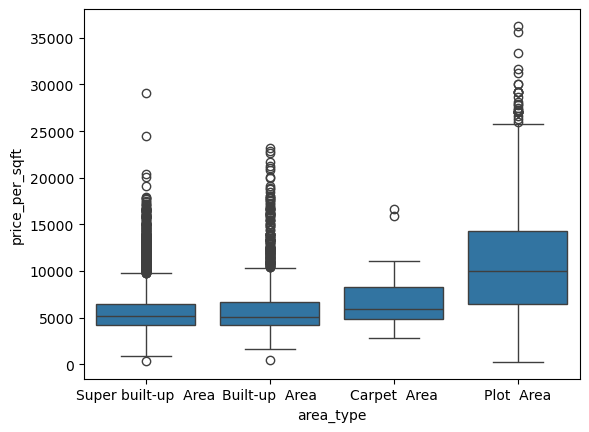

In [1680]:
sns.boxplot(x= df["area_type"], y= df["price_per_sqft"])

<Axes: xlabel='availability', ylabel='price'>

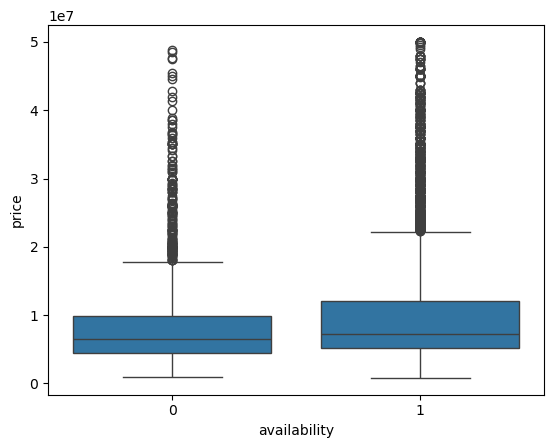

In [1681]:
sns.boxplot(x= df["availability"], y= df["price"])

1. Top 10 most expensive locations by average price per sqft
Ans: Bar Plot -> HAL 2nd Stage is the most expensive location at ~24,000 rupees per sqft. The top 10 locations are closely priced with no significant gap between them. This suggests Bangalore has a cluster of consistently premium areas. Location will be a strong predictor in the model.

2. What did you see in the boxplot of BHK vs price
Ans: Box Plot -> Price generally increases with BHK count from 1 to 4 BHK. Beyond 4 BHK the trend becomes inconsistent — likely because 5 and 6 BHK properties are fewer in number making the median less reliable. The relationship is not perfectly linear. High number of outliers across all categories suggests price is influenced by location more than BHK count alone

3. Bathrooms vs price
Ans: Box Plot -> Removed the incorrect bath values the data is somewhat linear But has too many outliers but we can see that it could be related to size more than price So if you combine bath and size we could predict the price more accurately

4. Distribution of BHK count
Ans: Count Plot -> data is baised for 2 and 3 bhk. It will predict these values more accurately that 1, 4, 5 etc

5. Does area type affect price per sqft
Ans: Box Plot -> Plot area being most expensive makes sense — you're buying land itself, not just a flat. Land in Bangalore is scarce and expensive. The box is also very wide meaning plot prices vary a lot depending on location. Super built-up and Built-up having most outliers — expected because they have the most listings (remember 8267 and 2381 from earlier). More data means more outliers naturally. Carpet area median similar to super built-up — this is actually interesting. Carpet area is the smallest measurement of a property yet priced similarly per sqft to super built-up. Meaning carpet area properties are genuinely more expensive per usable sqft — which makes real world sense.

6. Does availability affect price
Ans: Box Plot -> It doesnt and i should remove it.


This was before updating location before we to location.value_count greater that 10 but it created to much noise so later took location.value_count greater than 50. Also removed rows with price more than 5Cr.

In [1682]:
df.drop(columns= ['availability'], inplace= True)

In [1683]:
df.head()

,area_type,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606
155,Super built-up Area,Electronic City Phase II,2,1020.0,2,1,3060000.0,3000.000000
292,Super built-up Area,Electronic City Phase II,2,1069.0,2,2,4500000.0,4209.541628
354,Super built-up Area,Electronic City Phase II,1,630.0,1,1,2835000.0,4500.000000
461,Super built-up Area,Electronic City Phase II,3,1220.0,2,1,3523000.0,2887.704918


In [1684]:
df.shape

(11760, 8)

In [1685]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11760 entries, 0 to 12810
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       11760 non-null  object 
 1   location        11760 non-null  object 
 2   size            11760 non-null  int64  
 3   total_sqft      11760 non-null  float64
 4   bath            11760 non-null  int64  
 5   balcony         11760 non-null  int64  
 6   price           11760 non-null  float64
 7   price_per_sqft  11760 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 826.9+ KB


<Axes: >

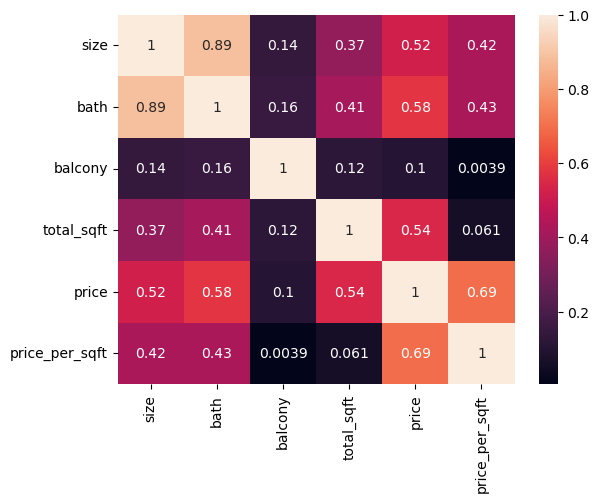

In [1686]:
cols = ['size', 'bath', 'balcony', 'total_sqft', 'price', 'price_per_sqft']
sns.heatmap(df[cols].corr(), annot= True)

In [1687]:
df2= df.copy()
df= pd.get_dummies(data= df, columns= ['area_type', 'location'], drop_first= True, dtype= int)

In [1688]:
df.shape

(11760, 53)

In [1689]:
df.head()

,size,total_sqft,bath,balcony,price,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
0,2,1056.0,2,1,3907000.0,3699.810606,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,1,3060000.0,3000.000000,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,2,4500000.0,4209.541628,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,1,2835000.0,4500.000000,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,1,3523000.0,2887.704918,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [1690]:
df.drop(columns= ['balcony', 'price_per_sqft'], inplace= True)

In [1691]:
df.head()

,size,total_sqft,bath,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
0,2,1056.0,2,3907000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,3060000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,4500000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,2835000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,3523000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [1692]:
from sklearn.model_selection import train_test_split

In [1693]:
X = df.drop('price', axis=1)
Y= df['price']

X.head()

D:\Studies\Anaconda\Lib\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
0,2,1056.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [1694]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [1695]:
X_train.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
1118,3,1665.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2615,3,1550.0,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7133,3,1430.0,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2689,2,950.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1610,3,1390.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [1740]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

Models to predict continuous Data 


1. Linear Regression
2. Ridge / Lasso Regression
3. Random Forest Regressor
4. XGBoost Regressor
5. SVR (Support Vector Regressor)
6. KNN Regressor
7. LightGBM
8. CatBoost


Needs scaling:
1. Linear Regression
2. Ridge / Lasso
3. SVR
4. KNN


Doesn't need scaling:
1. Random Forest
2. XGBoost
3. LightGBM
4. CatBoost
5. Decision Tree

In [1697]:
scaler= StandardScaler()

X_train_scaled= X_train.copy()
X_test_scaled= X_test.copy()
X_train_scaled[['total_sqft']]= scaler.fit_transform(X_train[['total_sqft']])
X_test_scaled[['total_sqft']]= scaler.transform(X_test[['total_sqft']])
Y_train_log = np.log(Y_train)
Y_test_log = np.log(Y_test)

In [1698]:
X_train.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
1118,3,1665.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2615,3,1550.0,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7133,3,1430.0,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2689,2,950.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1610,3,1390.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [1699]:
X_train_scaled.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
1118,3,0.155068,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2615,3,0.048169,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7133,3,-0.063378,3,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2689,2,-0.509566,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1610,3,-0.100560,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [1700]:
X_test.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
9482,4,3560.0,5,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2967,3,1340.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3452,2,1230.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8926,2,1215.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
8312,1,728.5,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [1701]:
X_test_scaled.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_8th Phase JP Nagar,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,...,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other
9482,4,1.916581,5,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2967,3,-0.147038,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3452,2,-0.249290,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8926,2,-0.263233,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
8312,1,-0.715463,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [1702]:
# Best one so far.
XGB_model = XGBRegressor(
    subsample=1,
    n_estimators=500,
    min_child_weight=5,
    max_depth=5,
    learning_rate=0.03,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [1703]:
XGB_model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [1704]:
XGB_pred= XGB_model.predict(X_test)

In [1705]:
print("r2:", r2_score(Y_test, XGB_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, XGB_pred)))
print("MAE:", mean_absolute_error(Y_test, XGB_pred))

r2: 0.7302250983955245
RMSE: 4259410.902184365
MAE: 2467559.3368409863


In [1706]:
df2.head()

,area_type,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606
155,Super built-up Area,Electronic City Phase II,2,1020.0,2,1,3060000.0,3000.000000
292,Super built-up Area,Electronic City Phase II,2,1069.0,2,2,4500000.0,4209.541628
354,Super built-up Area,Electronic City Phase II,1,630.0,1,1,2835000.0,4500.000000
461,Super built-up Area,Electronic City Phase II,3,1220.0,2,1,3523000.0,2887.704918


In [1707]:
df2['sqft_per_room']= df2['total_sqft']/df2['size']

In [1708]:
df2.head()

,area_type,location,size,total_sqft,bath,balcony,price,price_per_sqft,sqft_per_room
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606,528.000000
155,Super built-up Area,Electronic City Phase II,2,1020.0,2,1,3060000.0,3000.000000,510.000000
292,Super built-up Area,Electronic City Phase II,2,1069.0,2,2,4500000.0,4209.541628,534.500000
354,Super built-up Area,Electronic City Phase II,1,630.0,1,1,2835000.0,4500.000000,630.000000
461,Super built-up Area,Electronic City Phase II,3,1220.0,2,1,3523000.0,2887.704918,406.666667


In [1709]:
df2= df2[(df2['total_sqft']/df2['size'] >= 300) & (df2['total_sqft']/df2['size'] <= 1000)]

In [1710]:
df2['sqft_per_room'].describe()

count    10881.000000
mean       563.711476
std        121.598597
min        300.000000
25%        488.333333
50%        556.500000
75%        622.500000
max       1000.000000
Name: sqft_per_room, dtype: float64

In [1711]:
df2.shape

(10881, 9)

In [1712]:
df2.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'balcony',
       'price', 'price_per_sqft', 'sqft_per_room'],
      dtype='object')

In [1713]:
df2= pd.get_dummies(data= df2, columns= ['area_type'], drop_first= True, dtype= int)

In [1714]:
df2.head()

,location,size,total_sqft,bath,balcony,price,price_per_sqft,sqft_per_room,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606,528.000000,0,0,1
155,Electronic City Phase II,2,1020.0,2,1,3060000.0,3000.000000,510.000000,0,0,1
292,Electronic City Phase II,2,1069.0,2,2,4500000.0,4209.541628,534.500000,0,0,1
354,Electronic City Phase II,1,630.0,1,1,2835000.0,4500.000000,630.000000,0,0,1
461,Electronic City Phase II,3,1220.0,2,1,3523000.0,2887.704918,406.666667,0,0,1


In [1716]:
X2= df2.drop(columns= ['price', 'price_per_sqft'])
Y2= df2['price']

X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.20, random_state=42)

In [1719]:
X2_train.columns

Index(['location', 'size', 'total_sqft', 'bath', 'balcony', 'sqft_per_room',
       'area_type_Carpet  Area', 'area_type_Plot  Area',
       'area_type_Super built-up  Area'],
      dtype='object')

In [1720]:
Y2_train

8167      6500000.0
841       7500000.0
5944      6240000.0
2757      3500000.0
13194     7230000.0
            ...    
11500     6800000.0
10354     4800000.0
10774    22500000.0
1475      6800000.0
12995    12800000.0
Name: price, Length: 8704, dtype: float64

In [1722]:
temp= X2_train.join(Y2_train)

price_per_location= temp.groupby('location')['price'].mean()

In [1723]:
price_per_location.head()

location
7th Phase JP Nagar    9.707744e+06
8th Phase JP Nagar    5.816237e+06
Akshaya Nagar         7.751053e+06
Banashankari          8.107111e+06
Bannerghatta Road     8.033354e+06
Name: price, dtype: float64

In [1724]:
X2_train['location_encoded'] = X2_train['location'].map(price_per_location)
X2_test['location_encoded'] = X2_test['location'].map(price_per_location)

In [1751]:
X2_train.drop(columns= ['location'], inplace= True)
X2_test.drop(columns= ['location'], inplace= True)

,size,total_sqft,bath,balcony,sqft_per_room,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_encoded
9712,3,1850.0,3,2,616.666667,0,0,1,9.677361e+06
990,1,649.5,1,0,649.500000,0,0,1,6.238281e+06
7488,2,1019.0,2,1,509.500000,0,0,1,9.677361e+06
3290,3,1817.0,4,1,605.666667,0,0,1,9.677361e+06
2831,3,1535.0,3,1,511.666667,0,0,1,9.677361e+06
...,...,...,...,...,...,...,...,...,...
3588,4,3200.0,3,3,800.000000,0,0,1,9.677361e+06
9288,2,1095.0,2,1,547.500000,0,0,1,9.677361e+06
5458,3,1200.0,3,1,400.000000,0,1,0,9.677361e+06
10859,3,1935.0,4,2,645.000000,0,0,1,9.677361e+06


In [1735]:
X2_train_one_hot_encoding= X2_train.copy()
X2_test_one_hot_encoding= X2_test.copy()

In [1736]:
X2_train_one_hot_encoding= pd.get_dummies(data= X2_train_one_hot_encoding, columns= ['location'], drop_first= True, dtype= int)
X2_test_one_hot_encoding= pd.get_dummies(data= X2_test_one_hot_encoding, columns= ['location'], drop_first= True, dtype= int)

In [1744]:
LR_model_2_encoded= LinearRegression()

LR_model_2_encoded.fit(X2_train_one_hot_encoding, Y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1745]:
LR_pred_2_encoded= LR_model_2_encoded.predict(X2_test_one_hot_encoding)

In [1746]:
r2_score(Y2_test, LR_pred_2_encoded)

0.6783016232862525

In [1752]:
LR_model_2= LinearRegression()

LR_model_2.fit(X2_train, Y2_train)
LR_pred_2= LR_model_2.predict(X2_test)

r2_score(Y2_test, LR_pred_2)

0.6753544968406155

In [1753]:
model_rf= RandomForestRegressor()

model_rf.fit(X2_train_one_hot_encoding, Y2_train)

rf_2_pred= model_rf.predict(X2_test_one_hot_encoding)

r2_score(Y2_test, rf_2_pred)

0.7073885360162012

In [1754]:
model_XGB= XGBRegressor()

model_XGB.fit(X2_train_one_hot_encoding, Y2_train)

XGB_2_pred= model_XGB.predict(X2_test_one_hot_encoding)

r2_score(Y2_test, XGB_2_pred)

0.7356000153098847

In [1755]:
model_LGBM= LGBMRegressor()

model_LGBM.fit(X2_train_one_hot_encoding, Y2_train)

LGBM_2_pred= model_LGBM.predict(X2_test_one_hot_encoding)

r2_score(Y2_test, LGBM_2_pred)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 676
[LightGBM] [Info] Number of data points in the train set: 8704, number of used features: 53
[LightGBM] [Info] Start training from score 9182346.966912


0.7370302214684267

In [1756]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,            
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X2_train_one_hot_encoding, Y2_train)

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X2_test_one_hot_encoding)

print("Best Params:", random_search.best_params_)
print("Train R2:", r2_score(Y2_train, best_xgb.predict(X2_train_one_hot_encoding)))
print("Test R2 :", r2_score(Y2_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
Train R2: 0.7819472555559719
Test R2 : 0.7463033473409716


In [1759]:
xgb = XGBRegressor(
    n_estimators=700,
    reg_lambda=1,
    reg_alpha=0,
    max_depth=5,
    gamma=0,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X2_train_one_hot_encoding, Y2_train)

xgb_2_pred= xgb.predict(X2_test_one_hot_encoding)

print("Train R2:", r2_score(Y2_train, xgb.predict(X2_train_one_hot_encoding)))
r2_score(Y2_test, xgb_2_pred)

with open('model.pkl', 'wb') as f:
    pickle.dump('model.pkl', f)
    

Train R2: 0.7819472555559719


0.7463033473409716

In [1761]:
X2_train_one_hot_encoding.columns

Index(['size', 'total_sqft', 'bath', 'balcony', 'sqft_per_room',
       'area_type_Carpet  Area', 'area_type_Plot  Area',
       'area_type_Super built-up  Area', 'location_encoded',
       'location_8th Phase JP Nagar', 'location_Akshaya Nagar',
       'location_Banashankari', 'location_Bannerghatta Road',
       'location_Begur Road', 'location_Bellandur', 'location_Chandapura',
       'location_Electronic City', 'location_Electronic City Phase II',
       'location_Electronics City Phase 1', 'location_Haralur Road',
       'location_Harlur', 'location_Hebbal', 'location_Hennur Road',
       'location_Hoodi', 'location_Hormavu', 'location_Hosa Road',
       'location_Hulimavu', 'location_JP Nagar', 'location_Jakkur',
       'location_Jigani', 'location_KR Puram', 'location_Kaggadasapura',
       'location_Kanakpura Road', 'location_Kasavanhalli', 'location_Kengeri',
       'location_Koramangala', 'location_Kothanur', 'location_Malleshwaram',
       'location_Marathahalli', 'location_